<a href="https://colab.research.google.com/github/Soljafree60/git-work/blob/main/01_Analytical_Black_Scholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 01 — Analytical Black–Scholes Benchmark
## European Call Option



The Black–Scholes European call price is

$$
C(S,t)
=
SN(d_1)
-
Ke^{-r(T-t)}N(d_2),
$$

where

$$
d_1
=
\frac{
\ln(S/K)
+
\left(r+\frac12\sigma^2\right)(T-t)
}{
\sigma\sqrt{T-t}
},
$$

and

$$
d_2
=
d_1-\sigma\sqrt{T-t}.
$$

The analytical solution is used as the **ground-truth benchmark** for evaluating both the Crank–Nicolson FDM and the PINN.



## 1. Import the required libraries


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

print("NumPy version:", np.__version__)


NumPy version: 2.1.3



### Why I used this code

`NumPy` is used for numerical arrays and mathematical operations, `SciPy` provides the standard normal cumulative distribution function $N(\cdot)$, `pandas` is used to organise numerical outputs, and `Matplotlib` is used for figures (Harris et al., 2020; Virtanen et al., 2020; Hunter, 2007).

The Black–Scholes formula contains the normal cumulative distribution function $N(d_1)$ and $N(d_2)$, so `scipy.stats.norm.cdf` is an appropriate numerical implementation of that mathematical quantity (Black & Scholes, 1973; Hull, 2018).


## 2. Define the baseline Black–Scholes parameters


In [ ]:

S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0

print("S0 =", S0)
print("K =", K)
print("r =", r)
print("sigma =", sigma)
print("T =", T)


S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0



### Why these parameters are used

These values define the common baseline case used throughout the project:

$$
\begin{aligned}
S_0 &= 100, \\
K &= 100, \\
r &= 0.05, \\
\sigma &= 0.20, \\
T &= 1.
\end{aligned}
$$

Using one fixed baseline problem is important because it allows the analytical solution, FDM and PINN to be compared under identical market conditions before sensitivity experiments are introduced. The quantities $S$, $K$, $r$, $\sigma$ and $T$ are the standard inputs to the Black–Scholes European option model (Black & Scholes, 1973; Hull, 2018).


## 3. Implement the analytical European call formula


In [ ]:

def black_scholes_call(S, K, r, sigma, T, t=0.0):
    """
    Analytical Black-Scholes price for a European call option.

    Handles:
    - S = 0 safely
    - t = T by returning the terminal payoff
    """

    scalar_input = np.isscalar(S)
    S = np.asarray(S, dtype=float)

    tau = T - t

    if tau <= 0:
        result = np.maximum(S - K, 0.0)
        return float(result) if scalar_input else result

    result = np.zeros_like(S, dtype=float)

    positive = S > 0
    S_pos = S[positive]

    d1 = (
        np.log(S_pos / K)
        + (r + 0.5 * sigma**2) * tau
    ) / (sigma * np.sqrt(tau))

    d2 = d1 - sigma * np.sqrt(tau)

    result[positive] = (
        S_pos * norm.cdf(d1)
        - K * np.exp(-r * tau) * norm.cdf(d2)
    )

    return float(result) if scalar_input else result



### Why the analytical formula is implemented first

The analytical Black–Scholes solution is available for a European call under the assumptions of the model, making it an ideal benchmark for the numerical experiments (Black & Scholes, 1973; Hull, 2018).

The function is written so that it can accept either a single asset price or a vector of asset prices. This allowed the same implementation to be used for the baseline point $S_0=100$, one-dimensional price curves and two-dimensional $(S,t)$ grids.

Two numerical safeguards are included:

- at $S=0$, the code avoids evaluating $\ln(0)$;
- at $t=T$, it returns the payoff $\max(S-K,0)$ directly because the closed-form expressions for $d_1$ and $d_2$ contain $\sqrt{T-t}$ in the denominator.

These safeguards preserve the mathematical Black–Scholes solution while preventing avoidable numerical warnings.


## 4. Calculate the analytical baseline price at $S=100,t=0$


In [ ]:

analytical_price = black_scholes_call(
    S0,
    K,
    r,
    sigma,
    T,
    t=0.0
)

print(f"Black-Scholes Call Price: {analytical_price:.12f}")


Black-Scholes Call Price: 10.450583572186



### The result

This value is the reference price used to validate the FDM and PINN at the baseline point:

$$
C(100,0)\approx10.45058357.
$$

Because this value is generated directly from the analytical formula, it acts as the ground truth for the numerical pricing error calculations. The numerical value is the author's own computation, while the validity of the formula is supported by Black & Scholes (1973) and Hull (2018).




## 5. Plot analytical call price against the asset price


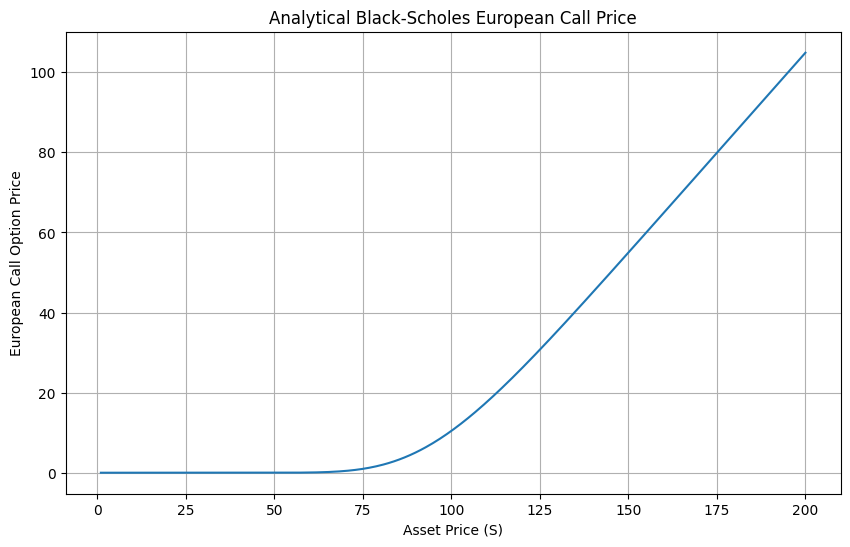

In [ ]:

S_values = np.linspace(
    1.0,
    200.0,
    400
)

call_prices = black_scholes_call(
    S_values,
    K,
    r,
    sigma,
    T,
    t=0.0
)

plt.figure(figsize=(10, 6))

plt.plot(
    S_values,
    call_prices
)

plt.xlabel("Asset Price (S)")
plt.ylabel("European Call Option Price")
plt.title("Analytical Black-Scholes European Call Price")
plt.grid(True)

plt.show()



### Why this figure is used

The one-dimensional analytical price curve provides a visual check of the expected relationship between the underlying asset price and a European call value. The option price should increase as $S$ increases under the Black–Scholes model (Hull, 2018).

This curve is also useful later because the FDM and PINN price curves can be plotted against the same analytical benchmark. Matplotlib is used only for visualisation (Hunter, 2007).




## 6. Generate the analytical solution over the full $(S,t)$ domain


In [ ]:

S_grid_values = np.linspace(
    0.0,
    200.0,
    200
)

t_grid_values = np.linspace(
    0.0,
    T,
    100
)

S_grid, t_grid = np.meshgrid(
    S_grid_values,
    t_grid_values
)

analytical_grid = np.zeros_like(
    S_grid,
    dtype=float
)

for j, t_value in enumerate(t_grid_values):
    analytical_grid[j, :] = black_scholes_call(
        S_grid_values,
        K,
        r,
        sigma,
        T,
        t=float(t_value)
    )

print("Analytical grid shape:", analytical_grid.shape)


Analytical grid shape: (100, 200)



### Why a full $(S,t)$ benchmark is generated

The research does not compare the methods only at one option price. Both the FDM and PINN aim to approximate the solution of the Black–Scholes PDE across a space-time domain. Creating an analytical grid therefore provides a reference surface against which the numerical solution can be checked throughout the domain.

The asset-price grid and time grid are generated with `NumPy`, which provides array-based numerical operations suited to this type of computational experiment (Harris et al., 2020).


## 7. Plot the analytical Black–Scholes solution surface as a contour map


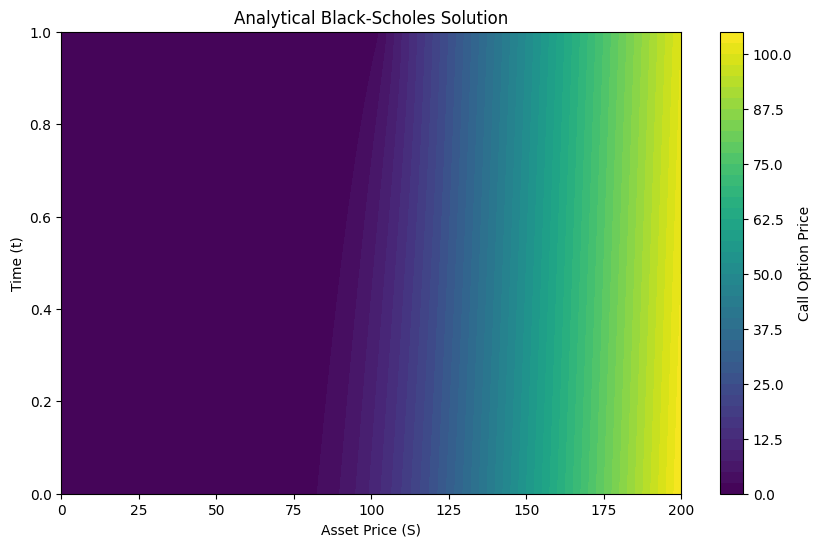

In [ ]:

plt.figure(figsize=(10, 6))

contour = plt.contourf(
    S_grid,
    t_grid,
    analytical_grid,
    levels=50
)

plt.colorbar(
    contour,
    label="Call Option Price"
)

plt.xlabel("Asset Price (S)")
plt.ylabel("Time (t)")
plt.title("Analytical Black-Scholes Solution")

plt.show()



### Why a contour plot is used

A contour plot shows how the option value changes simultaneously with asset price and time. This gives a more complete picture of the PDE solution than a single price or one-dimensional curve.

It also provides the visual benchmark that is later compared with the PINN solution surface. Matplotlib is used for the figure (Hunter, 2007).



## 8. Results summary

The analytical benchmark produced

$$
\boxed{C(100,0)=10.4505835722}.
$$

The analytical curve increases with the asset price, while the full $(S,t)$ contour provides the reference solution surface used later to assess numerical accuracy.





## References

Black, F. & Scholes, M. 1973. The pricing of options and corporate liabilities. *Journal of Political Economy*, 81(3):637-654. DOI: 10.1086/260062.

Crank, J. & Nicolson, P. 1947. A practical method for numerical evaluation of solutions of partial differential equations of the heat-conduction type. *Proceedings of the Cambridge Philosophical Society*, 43(1):50-67. DOI: 10.1017/S0305004100023197.

Duffy, D.J. 2006. *Finite difference methods in financial engineering: A partial differential equation approach*. Chichester: John Wiley & Sons. DOI: 10.1002/9781118673447.

Harris, C.R., Millman, K.J., van der Walt, S.J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N.J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M.H., Brett, M., Haldane, A., del Río, J.F., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C. & Oliphant, T.E. 2020. Array programming with NumPy. *Nature*, 585:357-362. DOI: 10.1038/s41586-020-2649-2.

Hull, J.C. 2018. *Options, futures, and other derivatives*. 10th ed. Harlow: Pearson.

Hunter, J.D. 2007. Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3):90-95. DOI: 10.1109/MCSE.2007.55.

Virtanen, P., Gommers, R., Oliphant, T.E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S.J., Brett, M., Wilson, J., Millman, K.J., Mayorov, N., Nelson, A.R.J., Jones, E., Kern, R., Larson, E., Carey, C.J., Polat, İ., Feng, Y., Moore, E.W., VanderPlas, J., Laxalde, D., Perktold, J., Cimrman, R., Henriksen, I., Quintero, E.A., Harris, C.R., Archibald, A.M., Ribeiro, A.H., Pedregosa, F., van Mulbregt, P. & SciPy 1.0 Contributors. 2020. SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17:261-272. DOI: 10.1038/s41592-019-0686-2.


